In [1]:
# import pandas as pd
# import os

# # 定义基础路径和要处理的文件列表
# base_path = '../../../5_Data/bupt_ring_selftest/wsx/报告/0526-1109-0527-1032/'
# # base_path = 'wang戒指/'
# # 根据截图生成 wang戒指1.csv 到 wang戒指4.csv
# file_names = [f'wang戒指{i}.csv' for i in range(1, 5)]

# all_parsed_rows = []

# # 遍历所有文件
# for file_name in file_names:
#     file_path = os.path.join(base_path, file_name)
#     print(f"正在处理: {file_name} ...")
    
#     current_date, current_time, current_offset = "", "", ""
    
#     try:
#         with open(file_path, 'r', encoding='utf-8') as file:
#             for line in file:
#                 line = line.strip()
                
#                 # 忽略空行和 '}'
#                 if not line or line == '}':
#                     continue
                
#                 # 提取时间戳逻辑
#                 if ',' in line:
#                     parts = line.split(',', 3)
#                     current_date = parts[0].strip()
#                     current_time = parts[1].strip()
#                     current_offset = parts[2].strip()
#                     # 增加健壮性，防止某些行只有逗号没有数据
#                     data_part = parts[3].strip() if len(parts) > 3 else "" 
#                 else:
#                     data_part = line
                    
#                 row_dict = {
#                     'File_Source': file_name,  # 添加文件来源标识，方便后续分析
#                     'Date': current_date,
#                     'Time': current_time,
#                     'Duration': current_offset
#                 }
                
#                 # 提取各个传感器数据
#                 if data_part:
#                     kv_pairs = data_part.split(';')
#                     for kv in kv_pairs:
#                         if ':' in kv:
#                             key, value = kv.split(':', 1)
#                             row_dict[key.strip()] = value.strip()
                            
#                     all_parsed_rows.append(row_dict)
                    
#     except FileNotFoundError:
#         print(f"⚠️ 警告: 未找到文件 {file_path}，已跳过。")

# # 将所有解析出的行转换为一个统一的 DataFrame
# df = pd.DataFrame(all_parsed_rows)

# print(f"\n✅ 数据拼接完成！合并后的 DataFrame 总行数: {len(df)}")
# df.to_csv(os.path.join(base_path, 'wang戒指_merged.csv'), index=False, encoding='utf-8') # 可选：将合并后的数据导出保存

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False    # 正常显示负号（关键！）

In [3]:
base_path = '../../../5_Data/bupt_ring_selftest/wsx/报告/0526-1109-0527-1032/'
df =  pd.read_csv(os.path.join(base_path, 'wang戒指_merged.csv'))

df['motion'] = np.abs(np.linalg.norm(df[['accX', 'accY', 'accZ']], axis=1) - 2200.)
df.ied = (-1.) * df.ied

df.drop("File_Source", inplace=True, axis=1)

In [4]:
df.dtypes

Date            str
Time            str
Duration        str
red         float64
ied         float64
accX        float64
accY        float64
accZ        float64
motion      float64
dtype: object

In [5]:
df.shape

(8506695, 9)

In [6]:
df.head()

,Date,Time,Duration,red,ied,accX,accY,accZ,motion
0,26-05-2026,11:15:41,0:00:00,12758212.0,-12114991.0,-1325.0,437.0,-1430.0,202.127632
1,26-05-2026,11:15:41,0:00:00,12759669.0,-12114665.0,-1332.0,434.0,-1434.0,195.271589
2,26-05-2026,11:15:41,0:00:00,12767971.0,-12115965.0,-1317.0,441.0,-1441.0,198.637714
3,26-05-2026,11:15:41,0:00:00,12780749.0,-12117369.0,-1317.0,436.0,-1447.0,195.406774
4,26-05-2026,11:15:41,0:00:00,12801215.0,-12123969.0,-1328.0,428.0,-1434.0,199.219152


In [7]:
import pandas as pd
import numpy as np
import math
import os
from tqdm import tqdm

def c_style_median_of_5(arr):
    tmp = list(arr) 
    for i in range(1, 5):
        key = tmp[i]
        j = i - 1
        while j >= 0 and tmp[j] > key:
            tmp[j + 1] = tmp[j]
            j -= 1
        tmp[j + 1] = key
    return tmp[2]

class RealTimePPGPipelineCommercial:
    def __init__(self, fs=100, chunk_size=100):
        self.fs = fs
        self.chunk_size = chunk_size
        self.time_per_point_ms = 1000.0 / fs
        
        self.baseline_1g = 0          
        self.prev_clean_y = None
        self.MAX_SLEW_RATE = 3000.0   

        self.med_buf = [0.0] * 5      
        self.med_idx = 0
        self.med_filled = False
        
        self.MA_WINDOW = 8            
        self.ma_buf = [0.0] * self.MA_WINDOW
        self.ma_idx = 0
        self.ma_sum = 0.0             
        self.ma_filled = False
        
        self.DC_ALPHA = 0.95          
        self.prev_raw_dc = None
        self.prev_ac_y = 0.0
        
        self.ac_y_history = []        
        self.global_idx = 0
        self.FILTER_DELAY = 5.5       

        self.PHASE_WAITING_FOR_VALLEY = 0
        self.PHASE_WAITING_FOR_PEAK = 1
        self.current_phase = self.PHASE_WAITING_FOR_VALLEY
        
        self.MIN_AC_AMP = 500.0
        self.upper_th = 5000.0
        self.lower_th = -5000.0
        
        # 【新增】：历史真实心跳幅值记忆，防止图3的伪影致盲
        self.recent_p2p = 800.0       
        
        self.local_max = float('-inf')
        self.local_max_x = 0
        self.local_min = float('inf')
        self.local_min_x = 0
        
        self.v1_x = 0                   
        self.v1_y = 0.0
        self.precise_v1_x = 0.0         
        
        self.backup_v1_x = 0
        self.backup_v1_y = 0.0
        self.backup_precise_v1_x = 0.0
        self.beat_just_added = False    
        
        self.run_sum = 0.0              
        self.run_enmo = 0.0             
        self.run_pts = 0                
        self.snap_area = 0.0            
        self.snap_enmo = 0.0
        self.snap_pts = 0
        self.area_up_saved = 0.0
        
        self.baseline_rri = 0.0
        self.display_hr_state = 0.0
        self.MIN_VALID_AMP = 15.0
        self.results = []

    def stage1_motion_and_polarity(self, row):
        raw_y = float(row.ied)
        acc_x, acc_y, acc_z = float(row.accX), float(row.accY), float(row.accZ)
        if math.isnan(acc_x) or math.isnan(acc_y) or math.isnan(acc_z):
            acc_norm = self.baseline_1g if self.baseline_1g != 0.0 else 2000.0 
        else:
            acc_norm = math.sqrt(acc_x**2 + acc_y**2 + acc_z**2)
        
        if self.baseline_1g == 0.0: self.baseline_1g = acc_norm
        enmo = abs(acc_norm - self.baseline_1g)
        if enmo < 300.0: self.baseline_1g = self.baseline_1g * 0.99 + acc_norm * 0.01
        time_str = f"{getattr(row, 'Date', '')} {getattr(row, 'Time', '')}".strip()
        return raw_y, enmo, time_str

    def stage2_preprocessing_c_style(self, raw_y):
        self.med_buf[self.med_idx] = raw_y
        self.med_idx = (self.med_idx + 1) % 5
        if self.med_idx == 0: self.med_filled = True
        median_y = c_style_median_of_5(self.med_buf) if self.med_filled else raw_y
            
        if self.prev_clean_y is None: clamped_y = median_y
        else:
            diff = median_y - self.prev_clean_y
            if diff > self.MAX_SLEW_RATE: clamped_y = self.prev_clean_y + self.MAX_SLEW_RATE
            elif diff < -self.MAX_SLEW_RATE: clamped_y = self.prev_clean_y - self.MAX_SLEW_RATE
            else: clamped_y = median_y
        self.prev_clean_y = clamped_y
            
        self.ma_sum = self.ma_sum - self.ma_buf[self.ma_idx] + clamped_y
        self.ma_buf[self.ma_idx] = clamped_y
        self.ma_idx = (self.ma_idx + 1) % self.MA_WINDOW
        if self.ma_idx == 0: self.ma_filled = True
        
        if self.ma_filled: ma_y = self.ma_sum / self.MA_WINDOW
        else:
            current_count = self.ma_idx if self.ma_idx > 0 else self.MA_WINDOW
            ma_y = self.ma_sum / current_count if current_count > 0 else clamped_y
            
        if self.prev_raw_dc is None: 
            self.prev_raw_dc = ma_y
            ac_y = 0.0
        else: 
            ac_y = ma_y - self.prev_raw_dc + self.DC_ALPHA * self.prev_ac_y
            
        self.prev_raw_dc = ma_y
        self.prev_ac_y = ac_y
        self.ac_y_history.append(ac_y)
        return ac_y

    def stage3_state_machine(self, ac_y, enmo, current_global_i, time_str):
        if ac_y > self.upper_th: self.upper_th = ac_y
        if ac_y < self.lower_th: self.lower_th = ac_y
            
        # 【修改 1】：加快包络线收缩速度 (256.0 -> 64.0)，让阈值在伪影后更快回落
        self.upper_th -= (self.upper_th - ac_y) / 64.0
        self.lower_th += (ac_y - self.lower_th) / 64.0
        
        p2p_amp = self.upper_th - self.lower_th
        if p2p_amp < self.MIN_AC_AMP: p2p_amp = self.MIN_AC_AMP

        # 【修改 2】：混合阈值。取当前包络与历史平均的较小值，彻底解决图 3 漏检
        dynamic_prom = min(p2p_amp * 0.20, self.recent_p2p * 0.30)
        
        prominence_th = dynamic_prom
        MAX_PROMINENCE = 1500.0  
        MIN_PROMINENCE = 150.0   
        if prominence_th > MAX_PROMINENCE: prominence_th = MAX_PROMINENCE
        elif prominence_th < MIN_PROMINENCE: prominence_th = MIN_PROMINENCE

        if self.current_phase == self.PHASE_WAITING_FOR_VALLEY:
            self.run_sum += ac_y
            self.run_enmo += enmo
            self.run_pts += 1
            
            if ac_y < self.local_min:
                self.local_min = ac_y
                self.local_min_x = current_global_i
                self.snap_area = self.run_sum
                self.snap_enmo = self.run_enmo
                self.snap_pts = self.run_pts
                
                # ====================================================
                # 【修改 3核心】：跨周期超级回溯 (Super Backtracking)
                # 解决图1、图2 绿点打在半山腰。若短时间内(1200ms)发生超越心跳级别的大崩盘，抹去假输出！
                # ====================================================
                if self.beat_just_added:
                    depth_diff = self.v1_y - ac_y
                    time_diff_ms = (current_global_i - self.v1_x) * self.time_per_point_ms
                    
                    if time_diff_ms < 1200.0 and depth_diff > (self.recent_p2p * 0.4):
                        if len(self.results) > 0:
                            self.results.pop()  # 吐出假点
                        self.beat_just_added = False
                        
                        # 时光倒流，旧坐标恢复
                        self.v1_x = self.backup_v1_x
                        self.v1_y = self.backup_v1_y
                        self.precise_v1_x = self.backup_precise_v1_x
            
            # 触发波谷
            if ac_y > (self.local_min + prominence_th):
                self.backup_v1_x = self.v1_x
                self.backup_v1_y = self.v1_y
                self.backup_precise_v1_x = self.precise_v1_x
                
                pre_results_len = len(self.results)
                self.stage4_feature_extraction(time_str)
                self.beat_just_added = len(self.results) > pre_results_len
                
                self.v1_x = self.local_min_x
                self.precise_v1_x = self.precise_v2_x 
                self.v1_y = self.local_min
                
                over_run_sum = self.run_sum - self.snap_area
                over_run_pts = self.run_pts - self.snap_pts
                carried_area = over_run_sum - (over_run_pts * self.v1_y)
                
                self.run_sum = carried_area if carried_area > 0 else 0.0
                self.run_enmo = self.run_enmo - self.snap_enmo
                self.run_pts = over_run_pts
                
                self.current_phase = self.PHASE_WAITING_FOR_PEAK
                self.local_max = ac_y  
                self.local_max_x = current_global_i

        elif self.current_phase == self.PHASE_WAITING_FOR_PEAK:
            current_height = ac_y - self.v1_y
            if current_height > 0: self.run_sum += current_height
            self.run_enmo += enmo
            self.run_pts += 1
            
            if ac_y > self.local_max:
                self.local_max = ac_y
                self.local_max_x = current_global_i
                self.snap_area = self.run_sum
                self.snap_enmo = self.run_enmo
                self.snap_pts = self.run_pts
                
            # 基础防错回溯（仍在寻峰期内跌破底线）
            if ac_y < self.v1_y:
                if self.beat_just_added and len(self.results) > 0:
                    self.results.pop()
                    self.beat_just_added = False
                
                self.v1_x = self.backup_v1_x
                self.v1_y = self.backup_v1_y
                self.precise_v1_x = self.backup_precise_v1_x
                
                self.current_phase = self.PHASE_WAITING_FOR_VALLEY
                self.local_min = ac_y
                self.local_min_x = current_global_i
                
                self.snap_area = self.run_sum
                self.snap_pts = self.run_pts
                self.snap_enmo = self.run_enmo
                return 

            # 触发波峰
            if ac_y < (self.local_max - prominence_th):
                self.area_up_saved = self.snap_area
                
                over_run_sum = self.run_sum - self.snap_area
                over_run_pts = self.run_pts - self.snap_pts
                self.run_sum = over_run_sum + (over_run_pts * self.v1_y)
                self.run_enmo = self.run_enmo - self.snap_enmo
                self.run_pts = over_run_pts
                
                self.current_phase = self.PHASE_WAITING_FOR_VALLEY
                self.local_min = ac_y 
                self.local_min_x = current_global_i

    def stage4_feature_extraction(self, time_str):
        v2_x = self.local_min_x
        v2_y = self.local_min
        
        delta_x = 0.0
        if 0 < v2_x < len(self.ac_y_history) - 1:
            y_m1 = self.ac_y_history[v2_x - 1]
            y_0  = self.ac_y_history[v2_x]
            y_p1 = self.ac_y_history[v2_x + 1]
            denom = y_m1 - 2 * y_0 + y_p1
            if denom != 0:
                delta_x = 0.5 * (y_m1 - y_p1) / denom
                delta_x = max(-1.0, min(1.0, delta_x)) 
                
        self.precise_v2_x = float(v2_x) + delta_x
        
        comp_peak_idx = max(0, int(round(self.local_max_x - self.FILTER_DELAY)))
        comp_valley_idx = max(0, int(round(v2_x - self.FILTER_DELAY)))
        
        if self.precise_v1_x > 0.0:
            rri_ms = (self.precise_v2_x - self.precise_v1_x) * self.time_per_point_ms
            area_down = self.snap_area - (self.snap_pts * v2_y)
            total_pts = self.snap_pts + self.run_pts
            
            if 300 <= rri_ms <= 2500 and area_down > 0:
                if self.baseline_rri == 0.0:
                    self.baseline_rri = rri_ms
                    self.display_hr_state = 60000.0 / rri_ms
                    
                is_valid_beat = True
                if rri_ms > self.baseline_rri * 1.8: is_valid_beat = False      
                elif rri_ms < self.baseline_rri * 0.45: is_valid_beat = False   
                elif rri_ms > 2000.0: is_valid_beat = False                
                    
                if is_valid_beat:
                    raw_hr = 60000.0 / rri_ms
                    self.baseline_rri = self.baseline_rri * 0.75 + rri_ms * 0.25
                    self.display_hr_state = self.display_hr_state * 0.85 + raw_hr * 0.15
                    motion_mean = (self.snap_enmo + self.run_enmo) / (total_pts if total_pts > 0 else 1)

                    amp_up = self.local_max - self.v1_y
                    amp_down = self.local_max - v2_y
                    
                    # 【修改 4】：平滑更新真实心跳的幅值，只对幅度合理的波形进行记忆
                    beat_amp = max(amp_up, amp_down)
                    if beat_amp > 100.0:  
                        self.recent_p2p = self.recent_p2p * 0.9 + beat_amp * 0.1

                    raw_area_up = self.area_up_saved if amp_up > self.MIN_VALID_AMP else 0.0
                    raw_area_down = area_down if amp_down > self.MIN_VALID_AMP else 0.0

                    self.results.append({
                        'Timestamp': time_str,
                        'RRI_ms': round(rri_ms, 2),
                        'HR_Raw': round(raw_hr, 1),
                        'HR_Display': int(self.display_hr_state),
                        'Area_Up': int(raw_area_up),
                        'Area_Down': int(raw_area_down),
                        'Motion': int(motion_mean) if not math.isnan(motion_mean) else 0,
                        'Peak_Index': comp_peak_idx,
                        'Valley_Index': comp_valley_idx,
                        'Filtered_Peak_Index': int(self.local_max_x),
                        'Filtered_Valley_Index': int(v2_x)
                    })

    def process_stream(self, df):
        total_rows = len(df)
        for start_idx in tqdm(range(0, total_rows, self.chunk_size), desc="C-Style Stream Pipeline", unit="chunk"):
            end_idx = min(start_idx + self.chunk_size, total_rows)
            chunk_df = df.iloc[start_idx:end_idx]
            for row in chunk_df.itertuples():
                raw_y, enmo, time_str = self.stage1_motion_and_polarity(row)
                ac_y = self.stage2_preprocessing_c_style(raw_y)
                self.stage3_state_machine(ac_y, enmo, self.global_idx, time_str)
                self.global_idx += 1
        return pd.DataFrame(self.results)

In [8]:
# 1. 实例化商业级 C 语言模拟流水线
# 请确保 fs (采样率) 与你实际硬件的采样率一致
pipeline_c = RealTimePPGPipelineCommercial(fs=100, chunk_size=100)

# 2. 传入你的 df 进行流式处理
# 此时终端或 Notebook 会显示 tqdm 进度条
print("开始执行纯 C 逻辑流式处理...")
final_results = pipeline_c.process_stream(df)

# 3. 查看输出的特征
print("\n✅ 处理完成！特征提取结果前 5 行:")
print(final_results.head())

# 4. (可选) 将结果保存为 CSV，方便后续对比或导入其他软件
final_results.to_csv("final_results.csv", index=False)

开始执行纯 C 逻辑流式处理...


C-Style Stream Pipeline: 100%|██████████████████████████████████████████████| 85067/85067 [00:53<00:00, 1575.32chunk/s]



✅ 处理完成！特征提取结果前 5 行:
             Timestamp   RRI_ms  HR_Raw  HR_Display  Area_Up  Area_Down  \
0  26-05-2026 11:15:53   360.00   166.7         122    95736     496131   
1  26-05-2026 11:15:57   845.53    71.0         114  1935647    1502523   
2  26-05-2026 11:15:57   510.39   117.6         114  1539967      11864   
3  26-05-2026 11:16:01   378.79   158.4         111   850356      42169   
4  26-05-2026 11:16:02  1067.87    56.2         103  1035073     949811   

   Motion  Peak_Index  Valley_Index  Filtered_Peak_Index  \
0     105        1194          1220                 1200   
1     234        1548          1598                 1554   
2     128        1638          1648                 1644   
3     272        2010          2020                 2015   
4     114        2112          2162                 2117   

   Filtered_Valley_Index  
0                   1226  
1                   1603  
2                   1654  
3                   2026  
4                   2168  


In [9]:
final_results.head()

,Timestamp,RRI_ms,HR_Raw,HR_Display,Area_Up,Area_Down,Motion,Peak_Index,Valley_Index,Filtered_Peak_Index,Filtered_Valley_Index
0,26-05-2026 11:15:53,360.00,166.7,122,95736,496131,105,1194,1220,1200,1226
1,26-05-2026 11:15:57,845.53,71.0,114,1935647,1502523,234,1548,1598,1554,1603
2,26-05-2026 11:15:57,510.39,117.6,114,1539967,11864,128,1638,1648,1644,1654
3,26-05-2026 11:16:01,378.79,158.4,111,850356,42169,272,2010,2020,2015,2026
4,26-05-2026 11:16:02,1067.87,56.2,103,1035073,949811,114,2112,2162,2117,2168


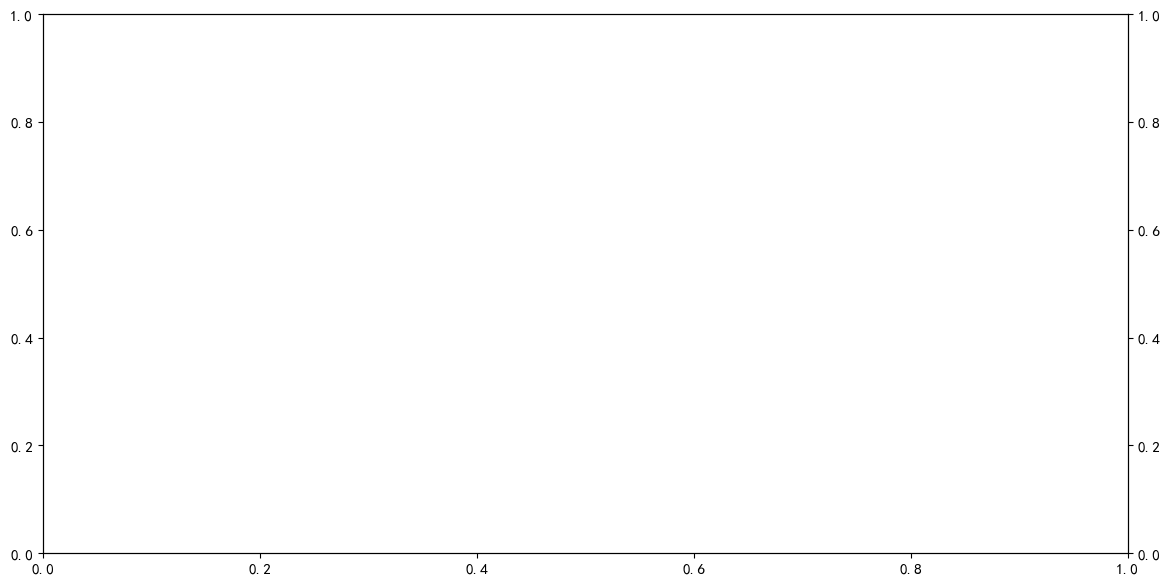

interactive(children=(IntSlider(value=2000, continuous_update=False, description='Start Idx:', max=8506495, st…

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Checkbox, VBox, HBox
from IPython.display import display, clear_output

# ==========================================
# 1. 准备数据 
# ==========================================
# 获取原始信号和运动数据
y_raw = df['ied'].values 
motion = df['motion'].values 

# 获取滤波后交流信号 (AC) - 假设你在 pipeline 跑完后保留了它
# 注意：你需要确保 pipeline_c.ac_y_history 能被访问到。
# 比如：y_ac = np.array(pipeline_c.ac_y_history)
try:
    y_ac = np.array(pipeline_c.ac_y_history)
except NameError:
    print("⚠️ 警告: 无法获取 ac_y_history，请确保 pipeline 实例存在。")
    y_ac = np.zeros_like(y_raw)

# 补偿后（对齐物理时间）的索引 —— 用于画在原始信号上
peaks_idx_comp = final_results['Peak_Index'].values
valleys_idx_comp = final_results['Valley_Index'].values
rri_values = final_results['RRI_ms'].values

# 补偿前（滤波域）的索引 —— 用于画在 AC 信号上对比
try:
    peaks_idx_filt = final_results['Filtered_Peak_Index'].values
    valleys_idx_filt = final_results['Filtered_Valley_Index'].values
except KeyError:
    print("⚠️ 警告: 未找到 Filtered_Index 列，请确认你的 Pipeline 代码已更新。")
    peaks_idx_filt = peaks_idx_comp
    valleys_idx_filt = valleys_idx_comp

plt.close('all')
clear_output(wait=True)

plt.ioff()  
plt.rcParams['font.size'] = 11
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx() 
plt.ion()   

# ==========================================
# 2. 交互式绘图函数
# ==========================================
@interact(
    start=IntSlider(min=0, max=len(y_raw)-200, step=100, value=2000, description='Start Idx:', continuous_update=False),
    window=IntSlider(min=200, max=5000, step=100, value=600, description='Window:', continuous_update=False),
    show_raw=Checkbox(value=True, description='显示原始信号 (Raw) & 对齐点', indent=False),
    show_ac=Checkbox(value=True, description='显示滤波信号 (AC) & 内部打点', indent=False)
)
def plot_zoom(start=0, window=600, show_raw=True, show_ac=True):
    
    ax1.cla()
    ax2.cla()
    
    end = min(start + window, len(y_raw))
    t = np.arange(start, end) / 100.0  
    
    # 获取切片数据
    current_raw = y_raw[start:end]
    current_ac = y_ac[start:end] if len(y_ac) >= end else np.zeros(end-start)
    
    # 计算均值，用于把原始信号和AC信号强行拉到同一个水平线附近对比
    raw_mean = np.nanmean(current_raw)
    current_raw_centered = current_raw - raw_mean
    
    lines_list = []
    labels_list = []

    # ==========================
    # 图层 A: 原始信号 & 补偿后的对齐点
    # ==========================
    if show_raw:
        l1, = ax1.plot(t, current_raw_centered, '-', color='#1f77b4', linewidth=1.5, alpha=0.9, label='Raw PPG (Centered)')
        lines_list.append(l1); labels_list.append(l1.get_label())
        
        # 提取当前窗口内的补偿点
        mask_p_comp = (peaks_idx_comp >= start) & (peaks_idx_comp < end)
        v_p_comp = peaks_idx_comp[mask_p_comp]
        
        mask_v_comp = (valleys_idx_comp >= start) & (valleys_idx_comp < end)
        v_v_comp = valleys_idx_comp[mask_v_comp]
        
        # 绘制补偿点 (打在 Raw 上)
        if len(v_p_comp) > 0:
            p_comp = ax1.plot(v_p_comp / 100.0, y_raw[v_p_comp] - raw_mean, 'ro', markersize=8, markeredgecolor='black', zorder=6, label='Compensated Peak (Raw)')
            lines_list.append(p_comp[0]); labels_list.append('Compensated Peak')
            
            valid_rris = rri_values[mask_p_comp]
            y_range = np.nanmax(current_raw_centered) - np.nanmin(current_raw_centered)
            for p_idx, rri in zip(v_p_comp, valid_rris):
                ax1.text(p_idx / 100.0, (y_raw[p_idx] - raw_mean) + y_range * 0.05, 
                         f'{int(rri)}ms', color='red', fontsize=10, ha='center', va='bottom', zorder=7)

        if len(v_v_comp) > 0:
            v_comp = ax1.plot(v_v_comp / 100.0, y_raw[v_v_comp] - raw_mean, 'go', markersize=8, markeredgecolor='black', zorder=6, label='Compensated Valley (Raw)')
            lines_list.append(v_comp[0]); labels_list.append('Compensated Valley')

    # ==========================
    # 图层 B: 滤波信号 (AC) & 补偿前的内部打点
    # ==========================
    if show_ac:
        l2, = ax1.plot(t, current_ac, '--', color='#ff7f0e', linewidth=1.5, alpha=0.8, label='Filtered AC Signal')
        lines_list.append(l2); labels_list.append(l2.get_label())
        
        # 提取当前窗口内的原始滤波点
        mask_p_filt = (peaks_idx_filt >= start) & (peaks_idx_filt < end)
        v_p_filt = peaks_idx_filt[mask_p_filt]
        
        mask_v_filt = (valleys_idx_filt >= start) & (valleys_idx_filt < end)
        v_v_filt = valleys_idx_filt[mask_v_filt]
        
        # 绘制滤波点 (打在 AC 上)
        if len(v_p_filt) > 0:
            p_filt = ax1.plot(v_p_filt / 100.0, y_ac[v_p_filt], 'rx', markersize=8, zorder=5, label='Filtered Peak (Internal)')
            lines_list.append(p_filt[0]); labels_list.append('Filtered Peak')
            
        if len(v_v_filt) > 0:
            v_filt = ax1.plot(v_v_filt / 100.0, y_ac[v_v_filt], 'gx', markersize=8, zorder=5, label='Filtered Valley (Internal)')
            lines_list.append(v_filt[0]); labels_list.append('Filtered Valley')

    # --- 统一调整 Y 轴范围 ---
    all_y = []
    if show_raw: all_y.extend(current_raw_centered)
    if show_ac: all_y.extend(current_ac)
    
    if len(all_y) > 0:
        slice_min, slice_max = np.nanmin(all_y), np.nanmax(all_y)
        y_padding = (slice_max - slice_min) * 0.15
        if slice_max == slice_min: y_padding = 10
        ax1.set_ylim([slice_min - y_padding, slice_max + y_padding*2])

    ax1.set_xlabel('Time (Seconds)', fontweight='bold')
    ax1.set_ylabel('Amplitude (Centered)', color='black')
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # --- 右轴绘制: Motion ---
    current_motion_slice = motion[start:end]
    ax2.fill_between(t, 0, current_motion_slice, color='gray', alpha=0.15)
    l3, = ax2.plot(t, current_motion_slice, color='gray', alpha=0.4, linewidth=1, label='Motion (ENMO)')
    lines_list.append(l3); labels_list.append(l3.get_label())
    
    if len(current_motion_slice) > 0:
        motion_max = np.nanmax(current_motion_slice)
        ax2.set_ylim([0, max(motion_max * 4.0, 100.0)]) 
        
    ax2.set_ylabel('Body Motion (ENMO)', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    # --- 图例与展示 ---
    ax1.legend(lines_list, labels_list, loc='upper right', framealpha=0.9)
    ax1.set_title(f'Phase Delay Analysis: Index {start} ~ {end} (Delay Comp: {pipeline_c.FILTER_DELAY} pts)', fontweight='bold')
    
    display(fig)

In [11]:
0.002*1e7

20000.0